In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score
from collections import Counter

df = pd.read_csv(r"C:\Users\lmutu\Downloads\911.csv\911.csv")


print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")

df.head()

Dataset shape: (99492, 9)

First 5 rows:


,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


In [2]:
# Cell 2: Check data types and missing values
print("Data types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print(f"\nPercentage missing in each column:")
print((df.isnull().sum() / len(df)) * 100)

Data types:
lat          float64
lng          float64
desc          object
zip          float64
title         object
timeStamp     object
twp           object
addr          object
e              int64
dtype: object

Missing values:
lat              0
lng              0
desc             0
zip          12855
title            0
timeStamp        0
twp             43
addr           519
e                0
dtype: int64

Percentage missing in each column:
lat           0.000000
lng           0.000000
desc          0.000000
zip          12.920637
title         0.000000
timeStamp     0.000000
twp           0.043220
addr          0.521650
e             0.000000
dtype: float64


In [3]:
print("=" * 80)
print("CLEAN KNN IMPUTATION - NO EXTRA COLUMNS")
print("=" * 80)

# Step 1: Drop 'e' column and rows with missing addresses
print("\n📊 Step 1: Basic data cleaning...")
original_count = len(df)

# Drop 'e' column if exists
if 'e' in df.columns:
    df = df.drop('e', axis=1)
    print("  ✅ Dropped 'e' column")

# Drop rows with missing addresses
addr_missing = df['addr'].isna() | (df['addr'] == '')
df = df[~addr_missing].copy()
print(f"  ✅ Dropped {original_count - len(df):,} rows with missing addresses")
print(f"  ✅ Remaining records: {len(df):,}")

# Step 2: Prepare ZIP and Township columns for imputation
print("\n📊 Step 2: Preparing for KNN imputation...")

# Clean ZIP column
df['zip'] = df['zip'].fillna('').astype(str).str.strip()
df['zip'] = df['zip'].replace(['', 'nan', 'NaN', 'none'], np.nan)
zip_missing_mask = df['zip'].isna()

# Clean Township column  
df['twp'] = df['twp'].fillna('').astype(str).str.strip().str.upper()
df['twp'] = df['twp'].replace(['', 'NAN', 'NONE'], np.nan)
twp_missing_mask = df['twp'].isna()

print(f"  - Missing ZIP codes: {zip_missing_mask.sum():,} ({zip_missing_mask.sum()/len(df)*100:.1f}%)")
print(f"  - Missing Townships: {twp_missing_mask.sum():,} ({twp_missing_mask.sum()/len(df)*100:.1f}%)")

# Step 3: KNN Prediction Function
def predict_with_knn(df, target_col, missing_mask, k=5):
    """
    Predict missing values using KNN based on lat/lng
    Returns: df with predictions filled (no extra columns)
    """
    # Get known data
    known_mask = (~missing_mask) & df['lat'].notna() & df['lng'].notna()
    known_data = df[known_mask].copy()
    
    # Get missing data
    missing_data = df[missing_mask & df['lat'].notna() & df['lng'].notna()].copy()
    
    if len(missing_data) == 0:
        print(f"  ✅ No missing {target_col} values to predict")
        return df
    
    print(f"  Predicting {len(missing_data):,} missing {target_col} values...")
    
    # Prepare coordinates
    coords_known = known_data[['lat', 'lng']].values
    coords_missing = missing_data[['lat', 'lng']].values
    
    # Standardize
    scaler = StandardScaler()
    coords_known_scaled = scaler.fit_transform(coords_known)
    coords_missing_scaled = scaler.transform(coords_missing)
    
    # KNN
    knn = NearestNeighbors(n_neighbors=k, metric='euclidean')
    knn.fit(coords_known_scaled)
    distances, indices = knn.kneighbors(coords_missing_scaled)
    
    # Predict using mode of neighbors
    predictions = []
    for neighbor_indices in indices:
        neighbor_values = known_data.iloc[neighbor_indices][target_col].values
        # Filter out NaN values
        valid_values = [v for v in neighbor_values if pd.notna(v)]
        if valid_values:
            most_common = Counter(valid_values).most_common(1)
            predictions.append(most_common[0][0])
        else:
            predictions.append(np.nan)
    
    # Fill predictions back to dataframe
    df.loc[missing_mask, target_col] = predictions
    
    print(f"  ✅ Predicted {len(predictions):,} {target_col} values")
    return df

# Step 4: Run KNN predictions
print("\n📊 Step 3: Running KNN predictions...")

# Predict ZIP codes
df = predict_with_knn(df, 'zip', zip_missing_mask, k=5)

# Predict Townships  
df = predict_with_knn(df, 'twp', twp_missing_mask, k=5)

# Step 5: Final check
print("\n📊 Step 4: Verification...")
final_zip_missing = df['zip'].isna().sum()
final_twp_missing = df['twp'].isna().sum()

print(f"  - Remaining missing ZIP: {final_zip_missing}")
print(f"  - Remaining missing Township: {final_twp_missing}")

# Step 6: Save final clean dataset (ORIGINAL COLUMNS ONLY)
print("\n📊 Step 5: Saving final dataset...")

# Keep only original columns (no extra columns added)
original_columns = ['lat', 'lng', 'desc', 'zip', 'title', 'timeStamp', 'twp', 'addr']
final_df = df[original_columns].copy()

# Save
final_df.to_csv('911_crises_response_final.csv', index=False)
print(f"✅ Saved: 911_crises_response_final.csv")
print(f"  - Shape: {final_df.shape}")
print(f"  - Columns: {final_df.columns.tolist()}")

print("\n" + "=" * 80)
print("FINAL DATASET SUMMARY")
print("=" * 80)

print(f"\n✅ Complete! Your dataset is now ready for the crisis response system:")
print(f"  - Total records: {len(final_df):,}")
print(f"  - Complete addresses: {len(final_df)}")
print(f"  - Complete ZIP codes: {(final_df['zip'].notna()).sum():,} ({(final_df['zip'].notna()).sum()/len(final_df)*100:.1f}%)")
print(f"  - Complete townships: {(final_df['twp'].notna()).sum():,} ({(final_df['twp'].notna()).sum()/len(final_df)*100:.1f}%)")

# Show sample
print("\n📋 Sample of final data (first 5 rows):")
print(final_df.head())

print("\n" + "=" * 80)
print("✅ READY FOR YOUR CRISIS RESPONSE SYSTEM!")
print("=" * 80)

CLEAN KNN IMPUTATION - NO EXTRA COLUMNS

📊 Step 1: Basic data cleaning...
  ✅ Dropped 'e' column
  ✅ Dropped 519 rows with missing addresses
  ✅ Remaining records: 98,973

📊 Step 2: Preparing for KNN imputation...
  - Missing ZIP codes: 12,383 (12.5%)
  - Missing Townships: 31 (0.0%)

📊 Step 3: Running KNN predictions...
  Predicting 12,383 missing zip values...
  ✅ Predicted 12,383 zip values
  Predicting 31 missing twp values...
  ✅ Predicted 31 twp values

📊 Step 4: Verification...
  - Remaining missing ZIP: 0
  - Remaining missing Township: 0

📊 Step 5: Saving final dataset...
✅ Saved: 911_crises_response_final.csv
  - Shape: (98973, 8)
  - Columns: ['lat', 'lng', 'desc', 'zip', 'title', 'timeStamp', 'twp', 'addr']

FINAL DATASET SUMMARY

✅ Complete! Your dataset is now ready for the crisis response system:
  - Total records: 98,973
  - Complete addresses: 98973
  - Complete ZIP codes: 98,973 (100.0%)
  - Complete townships: 98,973 (100.0%)

📋 Sample of final data (first 5 rows):
 

In [4]:
# Cell 1: Examine the actual data structure
print("Column names:")
print(df.columns.tolist())
print("\n" + "="*80)

# Look at the 'desc' column - this is where incident info is
print("\nFirst 20 'desc' values:")
for i in range(20):
    print(f"{i+1}. {df['desc'].iloc[i]}")

Column names:
['lat', 'lng', 'desc', 'zip', 'title', 'timeStamp', 'twp', 'addr']


First 20 'desc' values:
1. REINDEER CT & DEAD END;  NEW HANOVER; Station 332; 2015-12-10 @ 17:10:52;
2. BRIAR PATH & WHITEMARSH LN;  HATFIELD TOWNSHIP; Station 345; 2015-12-10 @ 17:29:21;
3. HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-Station:STA27;
4. AIRY ST & SWEDE ST;  NORRISTOWN; Station 308A; 2015-12-10 @ 16:47:36;
5. CHERRYWOOD CT & DEAD END;  LOWER POTTSGROVE; Station 329; 2015-12-10 @ 16:56:52;
6. CANNON AVE & W 9TH ST;  LANSDALE; Station 345; 2015-12-10 @ 15:39:04;
7. LAUREL AVE & OAKDALE AVE;  HORSHAM; Station 352; 2015-12-10 @ 16:46:48;
8. COLLEGEVILLE RD & LYWISKI RD;  SKIPPACK; Station 336; 2015-12-10 @ 16:17:05;
9. MAIN ST & OLD SUMNEYTOWN PIKE;  LOWER SALFORD; Station 344; 2015-12-10 @ 16:51:42;
10. BLUEROUTE  & RAMP I476 NB TO CHEMICAL RD; PLYMOUTH; 2015-12-10 @ 17:35:41;
11. RT202 PKWY & KNAPP RD; MONTGOMERY; 2015-12-10 @ 17:33:50;
12. BROOK RD & COLWELL LN; PLYMOUTH; 2015-12-10 @ 16:32

In [6]:
# Cell 4: Convert timestamps to datetime
# The data has two timestamp formats
print("Unique timestamp formats:")
print(df['timeStamp'].head(10))

# Parse the timestamps
def parse_timestamp(ts):
    if pd.isna(ts):
        return pd.NaT
    # Try format with @ (2015-12-10 @ 17:10:52)
    try:
        return pd.to_datetime(ts, format='%Y-%m-%d @ %H:%M:%S')
    except:
        pass
    # Try format without @ (2015-12-10 17:40:00)
    try:
        return pd.to_datetime(ts, format='%Y-%m-%d %H:%M:%S')
    except:
        return pd.NaT

df['incident_datetime'] = df['timeStamp'].apply(parse_timestamp)

# Check if conversion worked
print(f"\nSuccessfully parsed {df['incident_datetime'].notna().sum()} timestamps")
print(f"Date range: {df['incident_datetime'].min()} to {df['incident_datetime'].max()}")

Unique timestamp formats:
0    2015-12-10 17:40:00
1    2015-12-10 17:40:00
2    2015-12-10 17:40:00
3    2015-12-10 17:40:01
4    2015-12-10 17:40:01
5    2015-12-10 17:40:01
6    2015-12-10 17:40:01
7    2015-12-10 17:40:01
8    2015-12-10 17:40:01
9    2015-12-10 17:40:01
Name: timeStamp, dtype: object

Successfully parsed 98973 timestamps
Date range: 2015-12-10 17:40:00 to 2016-08-24 11:17:02


In [7]:
# Cell 5: Extract time features
df['incident_date'] = df['incident_datetime'].dt.date
df['incident_hour'] = df['incident_datetime'].dt.hour
df['incident_day'] = df['incident_datetime'].dt.day
df['incident_month'] = df['incident_datetime'].dt.month
df['incident_year'] = df['incident_datetime'].dt.year
df['incident_dayofweek'] = df['incident_datetime'].dt.dayofweek  # 0=Monday, 6=Sunday

# Create time-of-day categories
def time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['time_of_day'] = df['incident_hour'].apply(time_of_day)

print("Time features added successfully!")
print(df[['incident_datetime', 'incident_hour', 'time_of_day', 'incident_dayofweek']].head())

Time features added successfully!
    incident_datetime  incident_hour time_of_day  incident_dayofweek
0 2015-12-10 17:40:00             17     Evening                   3
1 2015-12-10 17:40:00             17     Evening                   3
2 2015-12-10 17:40:00             17     Evening                   3
3 2015-12-10 17:40:01             17     Evening                   3
4 2015-12-10 17:40:01             17     Evening                   3


In [8]:
# Cell 2: Examine the 'title' column - this might be cleaner
print("\nUnique values in 'title' column:")
print(df['title'].value_counts().head(30))

print("\n\nSample of 'title' with 'desc':")
for i in range(15):
    print(f"Title: {df['title'].iloc[i]}")
    print(f"Desc:  {df['desc'].iloc[i]}")
    print("-" * 60)


Unique values in 'title' column:
title
Traffic: VEHICLE ACCIDENT -             22910
Traffic: DISABLED VEHICLE -              7405
Fire: FIRE ALARM                         5496
EMS: RESPIRATORY EMERGENCY               5112
EMS: CARDIAC EMERGENCY                   5012
EMS: FALL VICTIM                         4863
EMS: VEHICLE ACCIDENT                    3935
Traffic: ROAD OBSTRUCTION -              3127
EMS: SUBJECT IN PAIN                     2687
EMS: HEAD INJURY                         2631
EMS: UNKNOWN MEDICAL EMERGENCY           1873
EMS: SYNCOPAL EPISODE                    1717
Fire: VEHICLE ACCIDENT                   1634
EMS: SEIZURES                            1630
EMS: GENERAL WEAKNESS                    1464
Fire: FIRE INVESTIGATION                 1460
EMS: ABDOMINAL PAINS                     1436
EMS: ALTERED MENTAL STATUS               1386
EMS: MEDICAL ALERT ALARM                 1342
EMS: HEMORRHAGING                        1259
EMS: CVA/STROKE                         

In [10]:
# Cell 3: Simplified version - guaranteed to return only 3 categories

def simple_categorize(title):
    """
    Simple categorization - always returns Medical, Fire, or Traffic
    """
    if pd.isna(title):
        return 'MEDICAL'
    
    title_str = str(title).upper()
    
    # Check for Fire
    if 'FIRE' in title_str:
        return 'FIRE'
    
    # Check for Traffic
    if 'TRAFFIC' in title_str or 'ACCIDENT' in title_str or 'VEHICLE' in title_str:
        return 'TRAFFIC'
    
    # Everything else is Medical (including EMS, medical emergencies, etc.)
    return 'MEDICAL'

# Apply simplified categorization
df['incident_type'] = df['title'].apply(simple_categorize)

print("="*60)
print("SIMPLIFIED 3-CATEGORY DISTRIBUTION")
print("="*60)
category_counts = df['incident_type'].value_counts()
for cat, count in category_counts.items():
    percentage = count / len(df) * 100
    print(f"  {cat:10} : {count:8,} ({percentage:.1f}%)")

print(f"\n✓ Categories: {list(df['incident_type'].unique())}")

SIMPLIFIED 3-CATEGORY DISTRIBUTION
  MEDICAL    :   44,599 (45.1%)
  TRAFFIC    :   38,592 (39.0%)
  FIRE       :   15,782 (15.9%)

✓ Categories: ['MEDICAL', 'FIRE', 'TRAFFIC']


In [11]:
# Cell 3: Verify that categorization is correct by sampling

print("="*60)
print("VERIFICATION - Sample incidents from each category")
print("="*60)

for incident_type in ['MEDICAL', 'FIRE', 'TRAFFIC']:
    print(f"\n--- {incident_type} INCIDENTS (Sample 3) ---")
    samples = df[df['incident_type'] == incident_type]['desc'].head(3)
    for i, sample in enumerate(samples, 1):
        print(f"  {i}. {sample[:100]}...")

VERIFICATION - Sample incidents from each category

--- MEDICAL INCIDENTS (Sample 3) ---
  1. REINDEER CT & DEAD END;  NEW HANOVER; Station 332; 2015-12-10 @ 17:10:52;...
  2. BRIAR PATH & WHITEMARSH LN;  HATFIELD TOWNSHIP; Station 345; 2015-12-10 @ 17:29:21;...
  3. AIRY ST & SWEDE ST;  NORRISTOWN; Station 308A; 2015-12-10 @ 16:47:36;...

--- FIRE INCIDENTS (Sample 3) ---
  1. HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-Station:STA27;...
  2. LILAC CT & PRIMROSE DR; UPPER GWYNEDD; 2015-12-10 @ 17:59:24-Station:STA80;...
  3. EDENTON PL & DURHAM DR; DELAWARE COUNTY; 2015-12-10 @ 18:05:19-Station:STA23;...

--- TRAFFIC INCIDENTS (Sample 3) ---
  1. BLUEROUTE  & RAMP I476 NB TO CHEMICAL RD; PLYMOUTH; 2015-12-10 @ 17:35:41;...
  2. RT202 PKWY & KNAPP RD; MONTGOMERY; 2015-12-10 @ 17:33:50;...
  3. BROOK RD & COLWELL LN; PLYMOUTH; 2015-12-10 @ 16:32:10;...


In [12]:
# Cell 4: Create encoded labels for machine learning

from sklearn.preprocessing import LabelEncoder

# Create label encoder for 3 categories
le_3 = LabelEncoder()
df['target_3'] = le_3.fit_transform(df['incident_type'])

# Show mapping
print("="*60)
print("3-CATEGORY MAPPING FOR ML")
print("="*60)
for i, category in enumerate(le_3.classes_):
    print(f"  {i} → {category}")

# Show distribution of encoded labels
print("\nEncoded label distribution:")
print(df['target_3'].value_counts().sort_index())

3-CATEGORY MAPPING FOR ML
  0 → FIRE
  1 → MEDICAL
  2 → TRAFFIC

Encoded label distribution:
target_3
0    15782
1    44599
2    38592
Name: count, dtype: int64


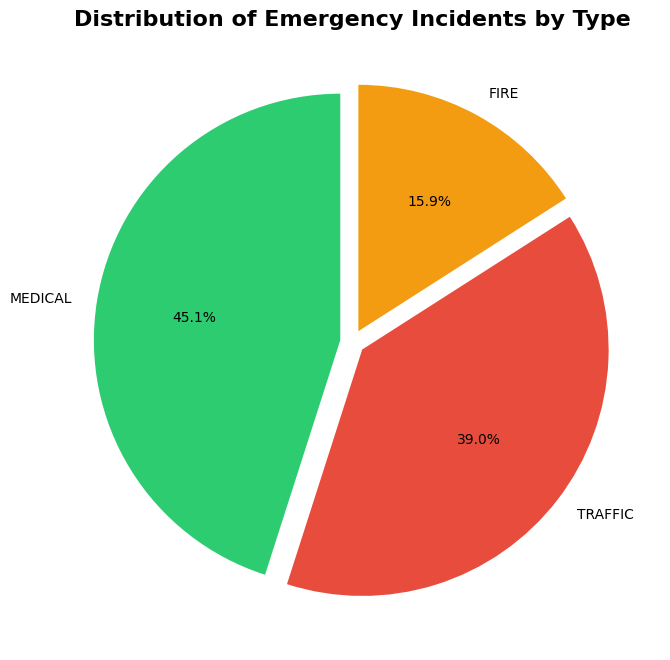

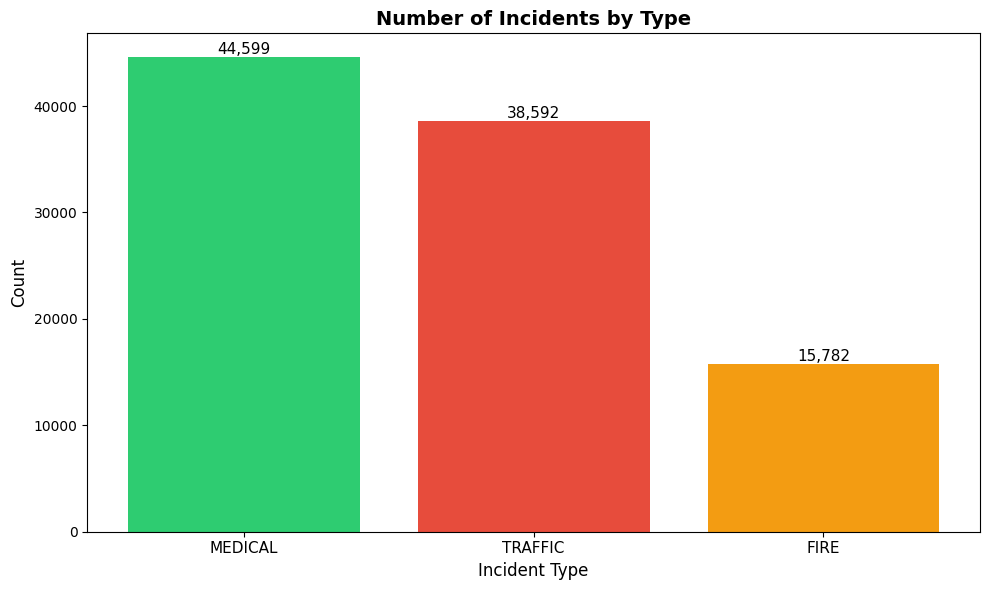

In [13]:
# Cell 5: Visualize the distribution

import matplotlib.pyplot as plt
import seaborn as sns

# Create a pie chart
plt.figure(figsize=(8, 8))
colors = ['#2ecc71', '#e74c3c', '#f39c12']  # Green, Red, Orange
plt.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90, explode=(0.05, 0.05, 0.05))
plt.title('Distribution of Emergency Incidents by Type', fontsize=16, fontweight='bold')
plt.show()

# Create a bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(category_counts.index, category_counts.values, color=colors)
plt.title('Number of Incidents by Type', fontsize=14, fontweight='bold')
plt.xlabel('Incident Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(fontsize=11)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

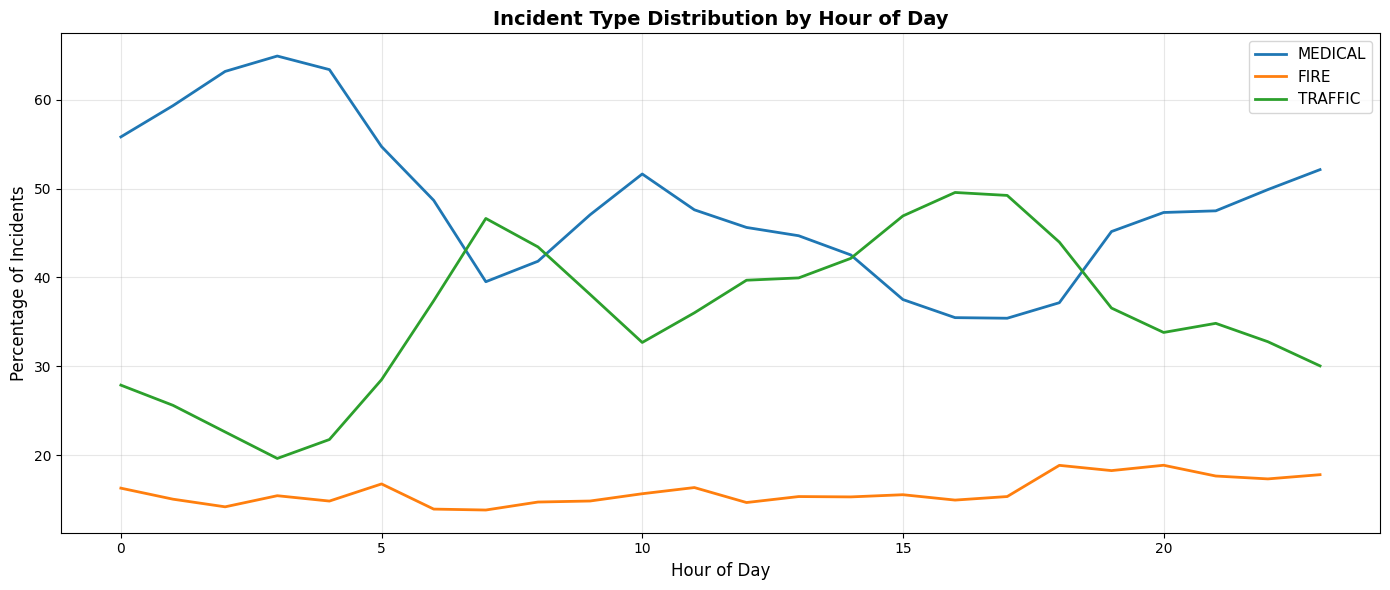

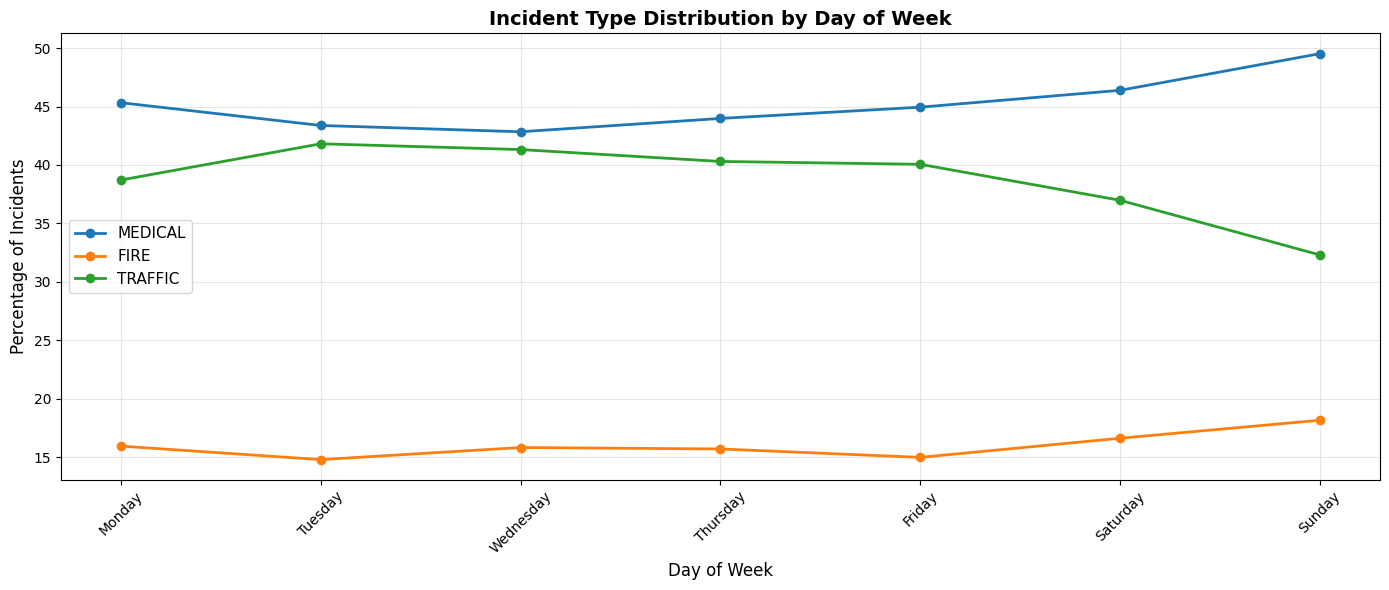

In [14]:
# Cell 6: Analyze when each incident type occurs

# By hour of day
hourly_distribution = pd.crosstab(df['incident_hour'], df['incident_type'], normalize='index') * 100

plt.figure(figsize=(14, 6))
for incident_type in ['MEDICAL', 'FIRE', 'TRAFFIC']:
    plt.plot(hourly_distribution.index, hourly_distribution[incident_type], 
             label=incident_type, linewidth=2)

plt.title('Incident Type Distribution by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Percentage of Incidents', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# By day of week
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_distribution = pd.crosstab(df['incident_dayofweek'], df['incident_type'], normalize='index') * 100

plt.figure(figsize=(14, 6))
for incident_type in ['MEDICAL', 'FIRE', 'TRAFFIC']:
    plt.plot(daily_distribution.index, daily_distribution[incident_type], 
             label=incident_type, linewidth=2, marker='o')

plt.title('Incident Type Distribution by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Percentage of Incidents', fontsize=12)
plt.xticks(range(7), days, rotation=45)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

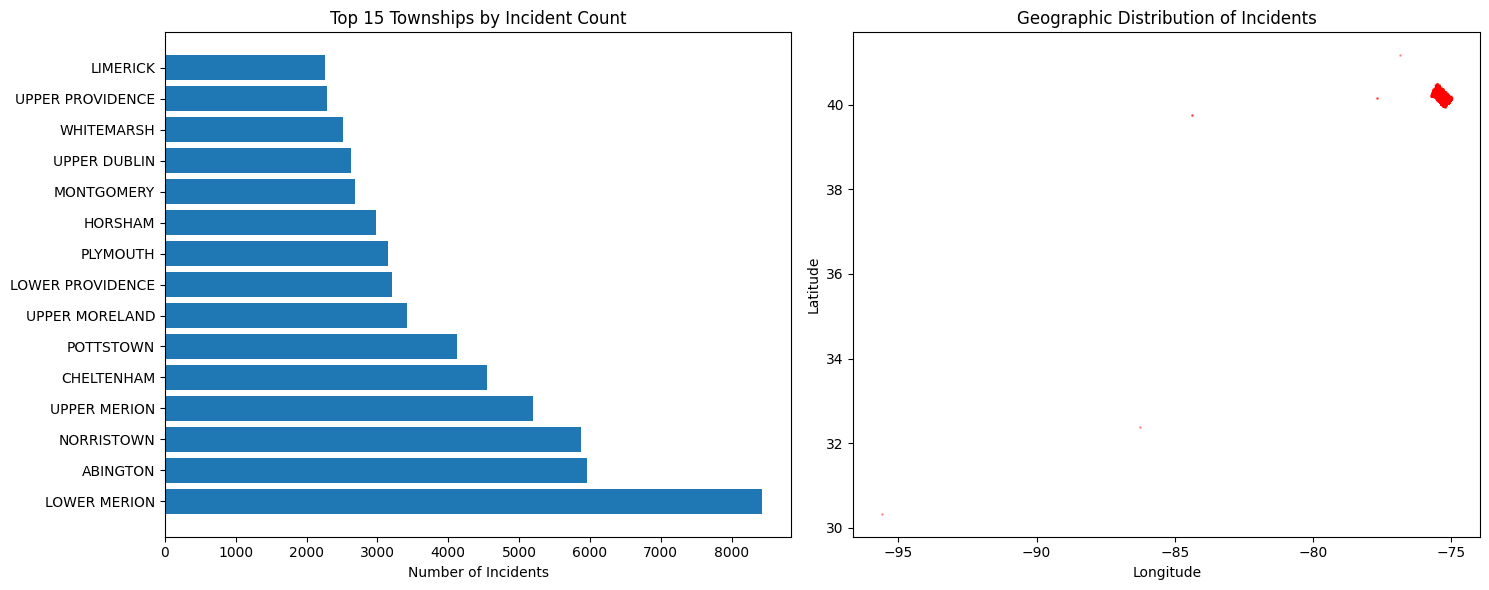


📊 Townships with most incidents:
   1. LOWER MERION: 8,425 incidents
   2. ABINGTON: 5,960 incidents
   3. NORRISTOWN: 5,879 incidents
   4. UPPER MERION: 5,204 incidents
   5. CHELTENHAM: 4,550 incidents


In [15]:
# Cell 3: Geographic patterns
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top townships
top_townships = df['twp'].value_counts().head(15)
axes[0].barh(range(len(top_townships)), top_townships.values)
axes[0].set_yticks(range(len(top_townships)))
axes[0].set_yticklabels(top_townships.index)
axes[0].set_title('Top 15 Townships by Incident Count', fontsize=12)
axes[0].set_xlabel('Number of Incidents')

# Incident density map (scatter plot)
axes[1].scatter(df['lng'], df['lat'], alpha=0.3, s=1, c='red')
axes[1].set_title('Geographic Distribution of Incidents', fontsize=12)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()

print(f"\n📊 Townships with most incidents:")
for i, (twp, count) in enumerate(top_townships.head(5).items()):
    print(f"   {i+1}. {twp}: {count:,} incidents")

In [16]:
# ============================================
# FEATURE ENGINEERING ONLY (No Repetition)
# Assuming df is already loaded and cleaned
# ============================================

from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import LabelEncoder
import numpy as np

print("="*70)
print("FEATURE ENGINEERING PIPELINE")
print("="*70)

print(f"\n📊 Starting with {len(df):,} records")
print(f"Current columns: {df.columns.tolist()}")

# ============================================
# 1. TIME-BASED FEATURES (from existing incident_datetime)
# ============================================
print("\n" + "="*50)
print("1. CREATING TIME-BASED FEATURES")
print("="*50)

# Assuming incident_datetime already exists from previous cleaning
if 'incident_datetime' not in df.columns:
    print("⚠️ incident_datetime not found! Converting timeStamp...")
    df['incident_datetime'] = pd.to_datetime(df['timeStamp'])

# Extract time features
df['hour'] = df['incident_datetime'].dt.hour
df['day_of_week'] = df['incident_datetime'].dt.dayofweek
df['month'] = df['incident_datetime'].dt.month
df['week_of_year'] = df['incident_datetime'].dt.isocalendar().week
df['quarter'] = df['incident_datetime'].dt.quarter

# Binary flags
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['is_rush_hour'] = df['hour'].isin([7, 8, 9, 16, 17, 18]).astype(int)
df['is_night'] = df['hour'].isin([22, 23, 0, 1, 2, 3, 4, 5]).astype(int)
df['is_morning_peak'] = df['hour'].isin([6, 7, 8, 9]).astype(int)
df['is_evening_peak'] = df['hour'].isin([16, 17, 18, 19]).astype(int)
df['is_lunch_hour'] = df['hour'].isin([12, 13]).astype(int)
df['is_holiday_season'] = df['month'].isin([11, 12]).astype(int)

time_features = ['hour', 'day_of_week', 'month', 'week_of_year', 'quarter', 
                 'is_weekend', 'is_rush_hour', 'is_night', 'is_morning_peak', 
                 'is_evening_peak', 'is_lunch_hour', 'is_holiday_season']
print(f"✅ Created {len(time_features)} time features")

# ============================================
# 2. SPATIAL FEATURES
# ============================================
print("\n" + "="*50)
print("2. CREATING SPATIAL FEATURES")
print("="*50)

# Clean coordinates (remove outliers)
df['lat_clean'] = df['lat'].clip(df['lat'].quantile(0.01), df['lat'].quantile(0.99))
df['lng_clean'] = df['lng'].clip(df['lng'].quantile(0.01), df['lng'].quantile(0.99))

# Location clusters using KMeans
coords = df[['lat_clean', 'lng_clean']].dropna().values
kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
df['location_cluster'] = kmeans.fit_predict(coords)

# Density-based clusters
dbscan = DBSCAN(eps=0.01, min_samples=10)
df['density_cluster'] = dbscan.fit_predict(coords)

# Distance from center
center_lat = df['lat_clean'].median()
center_lng = df['lng_clean'].median()
df['distance_from_center'] = np.sqrt(
    (df['lat_clean'] - center_lat)**2 + 
    (df['lng_clean'] - center_lng)**2
)

spatial_features = ['lat_clean', 'lng_clean', 'location_cluster', 'density_cluster', 'distance_from_center']
print(f"✅ Created {len(spatial_features)} spatial features")

# ============================================
# 3. LOCATION-BASED FEATURES
# ============================================
print("\n" + "="*50)
print("3. CREATING LOCATION-BASED FEATURES")
print("="*50)

# Encode township (using existing twp column)
le_township = LabelEncoder()
df['township_code'] = le_township.fit_transform(df['twp'].fillna('UNKNOWN'))
print(f"✅ Encoded {df['twp'].nunique()} townships")

# High-risk township flag (top 20%)
township_counts = df['twp'].value_counts()
high_risk_townships = township_counts[township_counts >= township_counts.quantile(0.8)].index
df['is_high_risk_township'] = df['twp'].isin(high_risk_townships).astype(int)

# Encode ZIP if available
if 'zip' in df.columns and df['zip'].notna().any():
    le_zip = LabelEncoder()
    df['zip_code'] = le_zip.fit_transform(df['zip'].fillna('UNKNOWN').astype(str))
    print(f"✅ Encoded {df['zip'].nunique()} ZIP codes")

location_features = ['township_code', 'is_high_risk_township']
if 'zip_code' in df.columns:
    location_features.append('zip_code')
print(f"✅ Created {len(location_features)} location features")

# ============================================
# 4. AGGREGATE FEATURES (Historical Patterns)
# ============================================
print("\n" + "="*50)
print("4. CREATING AGGREGATE FEATURES")
print("="*50)

# Historical incident rate by hour
hourly_counts = df.groupby('hour').size()
df['hourly_incident_rate'] = df['hour'].map(hourly_counts / hourly_counts.sum())

# Historical incident rate by township
township_counts_total = df.groupby('twp').size()
df['township_incident_rate'] = df['twp'].map(township_counts_total / township_counts_total.sum())

# Hour-township interaction rate
hour_township_counts = df.groupby(['hour', 'twp']).size()
township_totals = df.groupby('twp').size()
df['hour_township_rate'] = df.apply(
    lambda x: hour_township_counts.get((x['hour'], x['twp']), 0) / township_totals.get(x['twp'], 1), 
    axis=1
)

aggregate_features = ['hourly_incident_rate', 'township_incident_rate', 'hour_township_rate']
print(f"✅ Created {len(aggregate_features)} aggregate features")

# ============================================
# 5. INTERACTION FEATURES
# ============================================
print("\n" + "="*50)
print("5. CREATING INTERACTION FEATURES")
print("="*50)

df['weekend_rush_hour'] = df['is_weekend'] * df['is_rush_hour']
df['night_weekend'] = df['is_night'] * df['is_weekend']
df['month_hour'] = df['month'] * df['hour'] / 12
df['cluster_hour'] = df['location_cluster'] * df['hour'] / 23

interaction_features = ['weekend_rush_hour', 'night_weekend', 'month_hour', 'cluster_hour']
print(f"✅ Created {len(interaction_features)} interaction features")

# ============================================
# 6. TARGET VARIABLE (from existing title column)
# ============================================
print("\n" + "="*50)
print("6. CREATING TARGET VARIABLE")
print("="*50)

def create_target(title):
    if pd.isna(title):
        return 0
    title_str = str(title).upper()
    if 'FIRE:' in title_str:
        return 1
    elif 'TRAFFIC:' in title_str:
        return 2
    else:
        return 0

df['target'] = df['title'].apply(create_target)
df['target_label'] = df['target'].map({0: 'MEDICAL', 1: 'FIRE', 2: 'TRAFFIC'})

print(f"✅ Target variable created:")
for label in [0, 1, 2]:
    count = (df['target'] == label).sum()
    print(f"   {label}= {count:,} ({count/len(df)*100:.1f}%)")

# ============================================
# 7. SELECT FINAL FEATURES
# ============================================
print("\n" + "="*50)
print("7. SELECTING FINAL FEATURES")
print("="*50)

# All feature columns (no duplicates, only new ones)
feature_columns = (
    time_features + 
    spatial_features + 
    location_features + 
    aggregate_features + 
    interaction_features
)

# Keep only features that exist
existing_features = [col for col in feature_columns if col in df.columns]
print(f"✅ Selected {len(existing_features)} features for modeling")

# Create feature matrix
X = df[existing_features].copy()
y = df['target'].copy()

print(f"\n📊 Feature matrix shape: {X.shape}")
print(f"📊 Target shape: {y.shape}")

# ============================================
# 8. SAVE FEATURE-ENGINEERED DATASET
# ============================================
print("\n" + "="*50)
print("8. SAVING FEATURE-ENGINEERED DATASET")
print("="*50)

# Save all original + new features (no duplicates)
df.to_csv('911_feature_engineered.csv', index=False)
print(f"✅ Saved to '911_feature_engineered.csv'")

# ============================================
# 9. SUMMARY
# ============================================
print("\n" + "="*70)
print("FEATURE ENGINEERING SUMMARY")
print("="*70)

print(f"\n📊 Total new features added: {len(existing_features)}")
print(f"\n📊 Feature breakdown:")
print(f"   Time features: {len([c for c in existing_features if c in time_features])}")
print(f"   Spatial features: {len([c for c in existing_features if c in spatial_features])}")
print(f"   Location features: {len([c for c in existing_features if c in location_features])}")
print(f"   Aggregate features: {len([c for c in existing_features if c in aggregate_features])}")
print(f"   Interaction features: {len([c for c in existing_features if c in interaction_features])}")

print("\n📋 Sample of engineered features:")
print(X.head())

print("\n" + "="*70)
print("✅ FEATURE ENGINEERING COMPLETE! READY FOR MODELING.")
print("="*70)

FEATURE ENGINEERING PIPELINE

📊 Starting with 98,973 records
Current columns: ['lat', 'lng', 'desc', 'zip', 'title', 'timeStamp', 'twp', 'addr', 'incident_datetime', 'incident_date', 'incident_hour', 'incident_day', 'incident_month', 'incident_year', 'incident_dayofweek', 'time_of_day', 'incident_type', 'target_3']

1. CREATING TIME-BASED FEATURES
✅ Created 12 time features

2. CREATING SPATIAL FEATURES
✅ Created 5 spatial features

3. CREATING LOCATION-BASED FEATURES
✅ Encoded 68 townships
✅ Encoded 103 ZIP codes
✅ Created 3 location features

4. CREATING AGGREGATE FEATURES
✅ Created 3 aggregate features

5. CREATING INTERACTION FEATURES
✅ Created 4 interaction features

6. CREATING TARGET VARIABLE
✅ Target variable created:
   0= 48,877 (49.4%)
   1= 14,900 (15.1%)
   2= 35,196 (35.6%)

7. SELECTING FINAL FEATURES
✅ Selected 27 features for modeling

📊 Feature matrix shape: (98973, 27)
📊 Target shape: (98973,)

8. SAVING FEATURE-ENGINEERED DATASET
✅ Saved to '911_feature_engineered.c

FEATURE ENGINEERING VISUALIZATION DASHBOARD

📊 Dataset shape: (98973, 47)
📊 Features available: 47

1. TIME-BASED FEATURES ANALYSIS


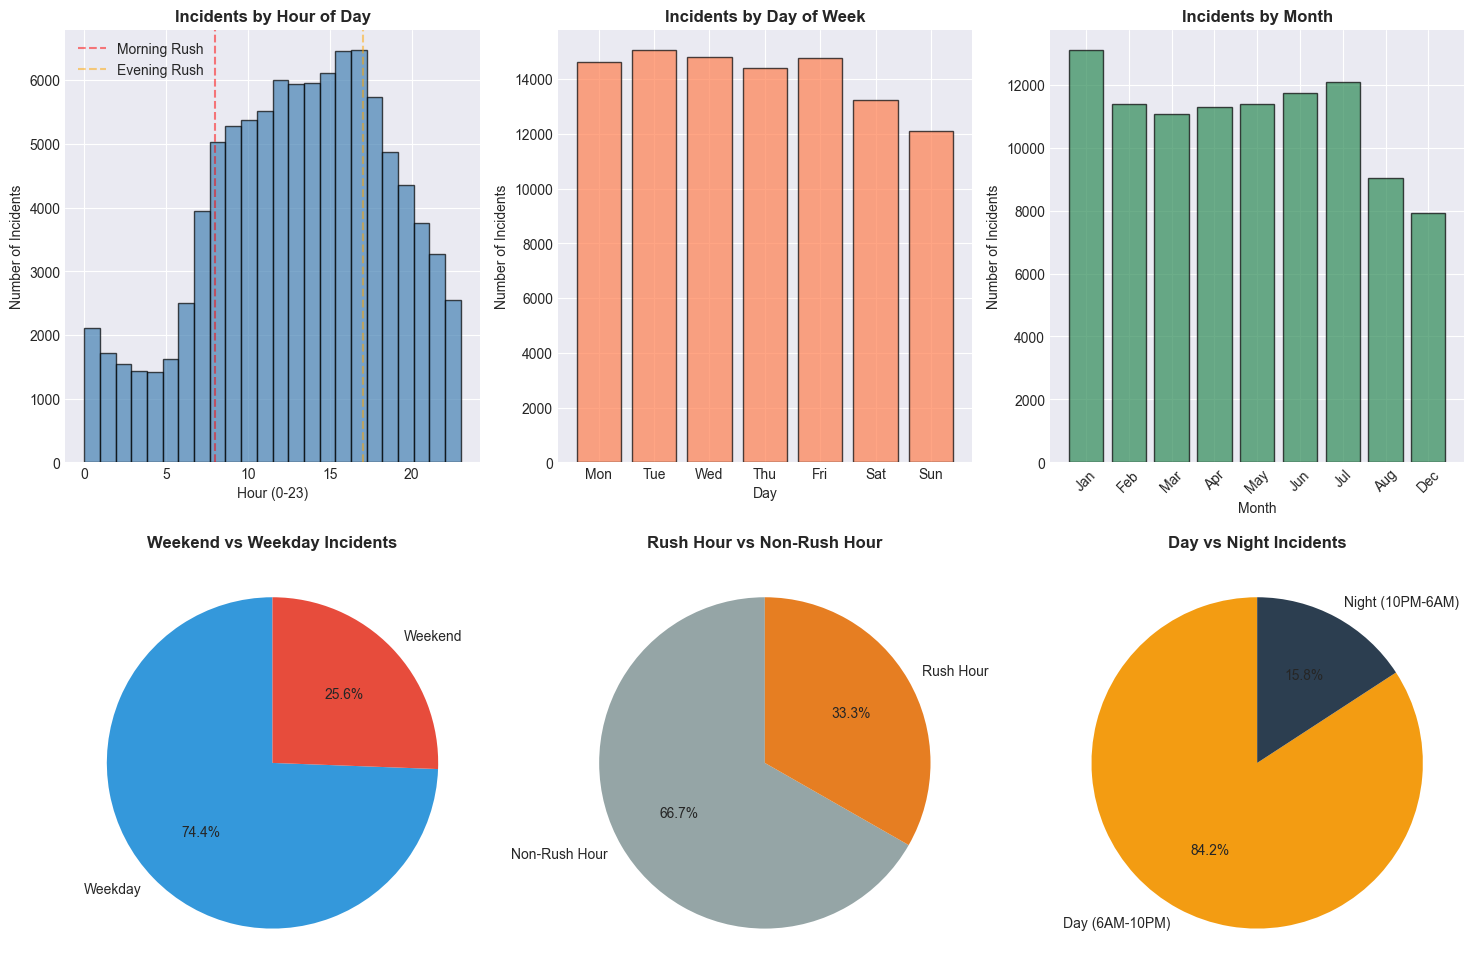


2. SPATIAL FEATURES ANALYSIS


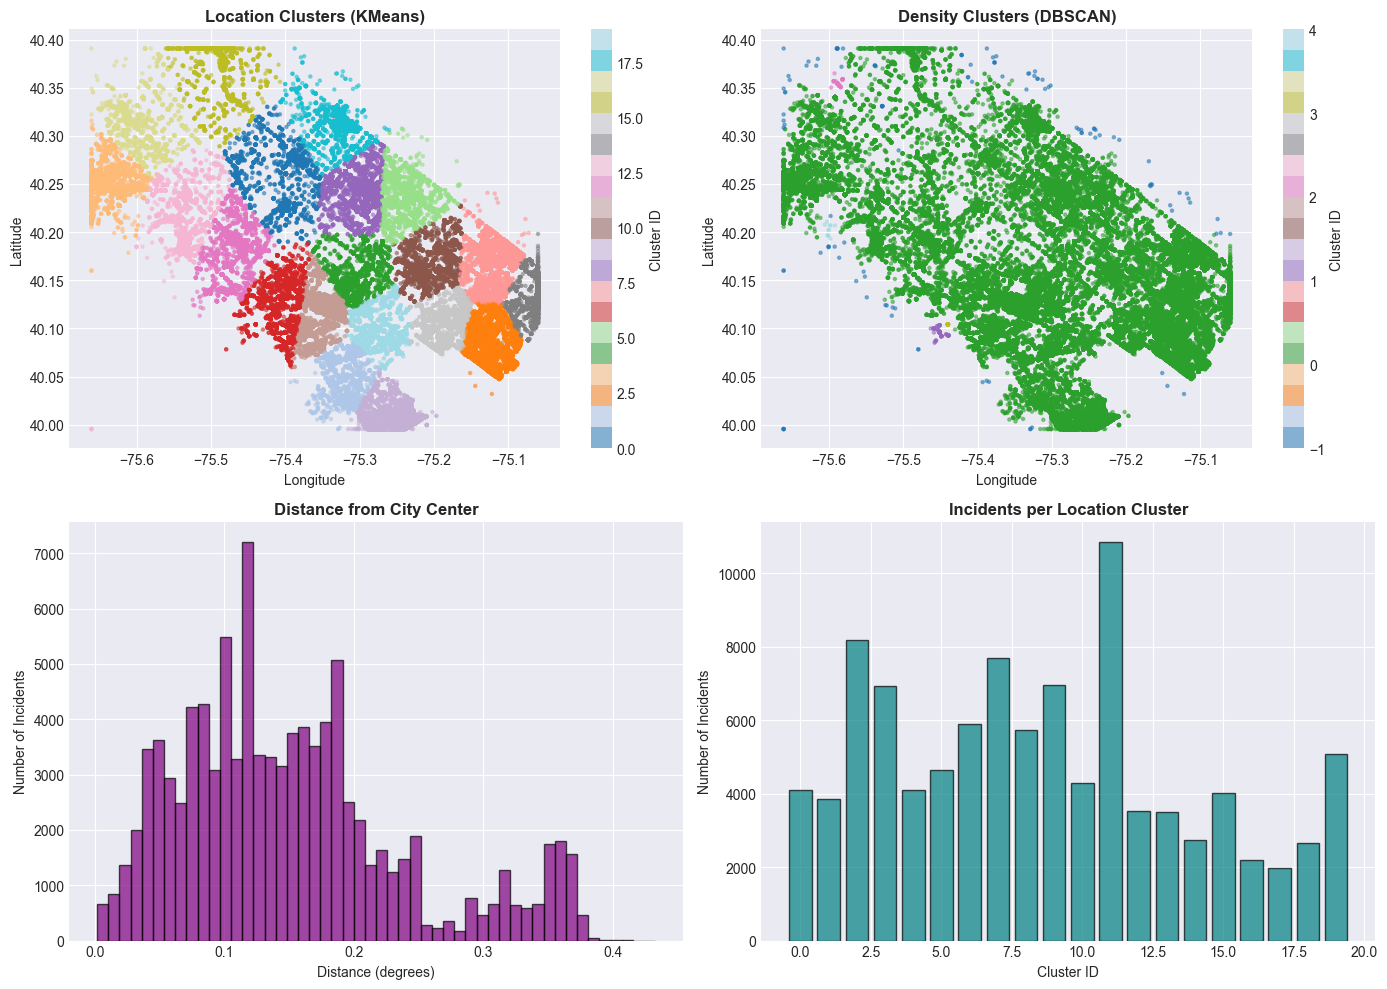


3. LOCATION-BASED FEATURES ANALYSIS


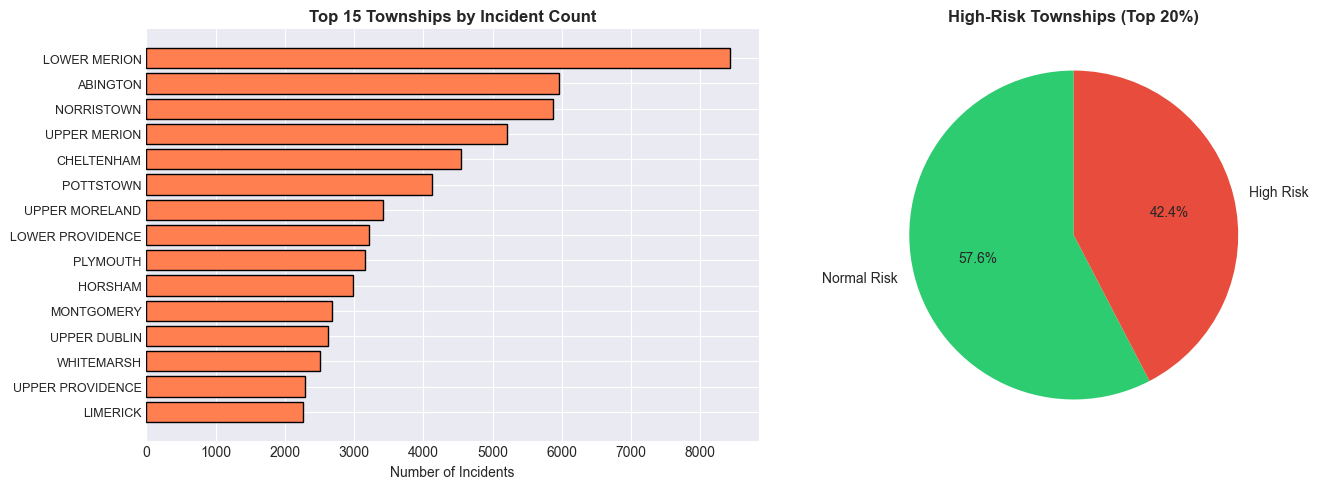


4. AGGREGATE FEATURES ANALYSIS


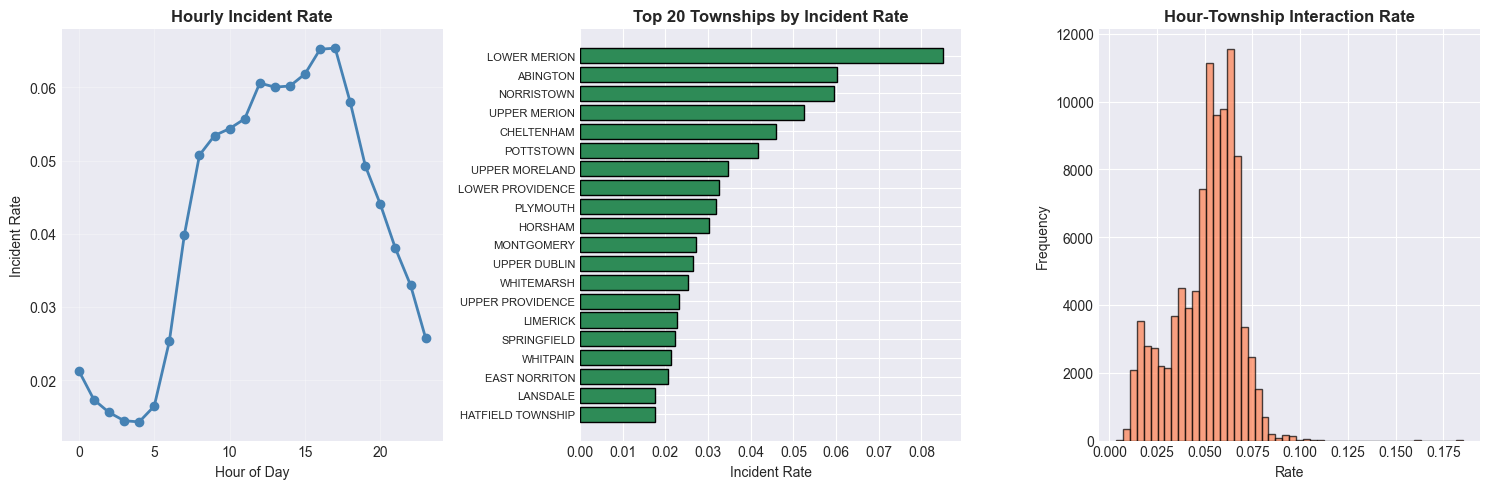


5. TARGET VARIABLE ANALYSIS


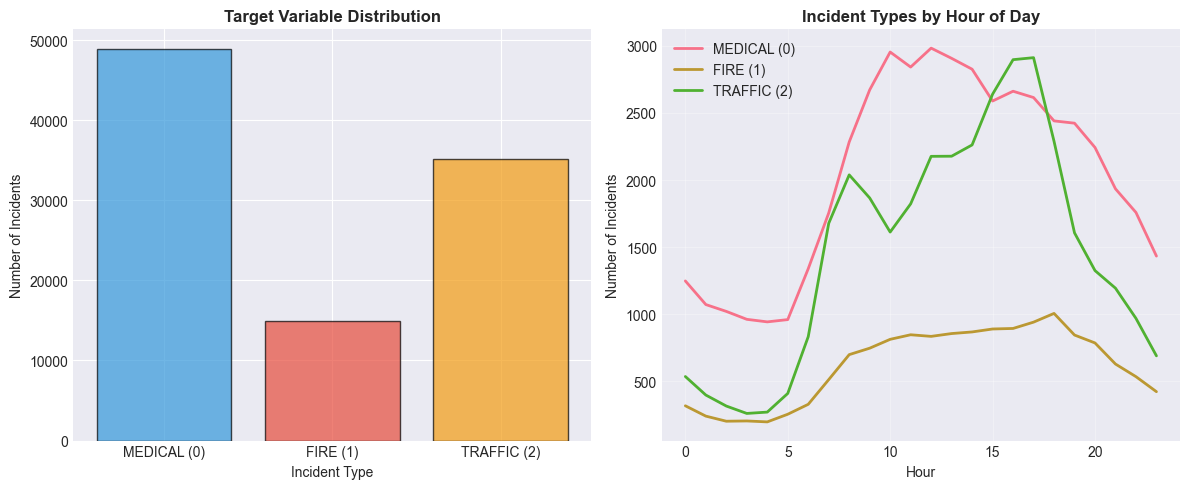


6. FEATURE ENGINEERING SUMMARY

📊 FINAL FEATURE SET:
   Total records: 98,973
   Total columns: 47

   Time features created:
   - 12 time features: ['hour', 'day_of_week', 'month', 'week_of_year', 'quarter']...

   Spatial features created:
   - 5 spatial features: ['lat_clean', 'lng_clean', 'location_cluster', 'density_cluster', 'distance_from_center']

   Location features created:
   - 3 location features: ['township_code', 'is_high_risk_township', 'zip_code']

   Aggregate features created:
   - 3 aggregate features: ['hourly_incident_rate', 'township_incident_rate', 'hour_township_rate']

   Interaction features created:
   - 4 interaction features: ['weekend_rush_hour', 'night_weekend', 'month_hour', 'cluster_hour']

📊 Target variable:
   MEDICAL: 48,877 (49.4%)
   FIRE: 14,900 (15.1%)
   TRAFFIC: 35,196 (35.6%)

✅ FEATURE ENGINEERING VISUALIZATION COMPLETE!


In [18]:
# ============================================
# FEATURE ENGINEERING VISUALIZATION (FIXED)
# See what features you've created
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("FEATURE ENGINEERING VISUALIZATION DASHBOARD")
print("="*80)

print(f"\n📊 Dataset shape: {df.shape}")
print(f"📊 Features available: {len(df.columns)}")

# ============================================
# 1. TIME-BASED FEATURES VISUALIZATION
# ============================================
print("\n" + "="*60)
print("1. TIME-BASED FEATURES ANALYSIS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Hour distribution
axes[0,0].hist(df['hour'].dropna(), bins=24, edgecolor='black', alpha=0.7, color='steelblue')
axes[0,0].set_title('Incidents by Hour of Day', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Hour (0-23)')
axes[0,0].set_ylabel('Number of Incidents')
axes[0,0].axvline(x=8, color='red', linestyle='--', alpha=0.5, label='Morning Rush')
axes[0,0].axvline(x=17, color='orange', linestyle='--', alpha=0.5, label='Evening Rush')
axes[0,0].legend()

# Day of week distribution
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_counts = df['day_of_week'].value_counts().sort_index()
axes[0,1].bar(days[:len(day_counts)], day_counts.values, edgecolor='black', alpha=0.7, color='coral')
axes[0,1].set_title('Incidents by Day of Week', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Day')
axes[0,1].set_ylabel('Number of Incidents')

# Month distribution (FIXED - handle missing months)
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_counts = df['month'].value_counts().sort_index()
# Only show months that have data
available_months = [months[i-1] for i in month_counts.index]
axes[0,2].bar(available_months, month_counts.values, edgecolor='black', alpha=0.7, color='seagreen')
axes[0,2].set_title('Incidents by Month', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel('Month')
axes[0,2].set_ylabel('Number of Incidents')
axes[0,2].tick_params(axis='x', rotation=45)

# Weekend vs Weekday
weekend_data = df['is_weekend'].value_counts()
labels = ['Weekday', 'Weekend']
colors_wk = ['#3498db', '#e74c3c']
axes[1,0].pie(weekend_data.values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors_wk)
axes[1,0].set_title('Weekend vs Weekday Incidents', fontsize=12, fontweight='bold')

# Rush hour vs Non-rush hour
rush_data = df['is_rush_hour'].value_counts()
labels_rush = ['Non-Rush Hour', 'Rush Hour']
axes[1,1].pie(rush_data.values, labels=labels_rush, autopct='%1.1f%%', startangle=90, colors=['#95a5a6', '#e67e22'])
axes[1,1].set_title('Rush Hour vs Non-Rush Hour', fontsize=12, fontweight='bold')

# Night vs Day
night_data = df['is_night'].value_counts()
labels_night = ['Day (6AM-10PM)', 'Night (10PM-6AM)']
axes[1,2].pie(night_data.values, labels=labels_night, autopct='%1.1f%%', startangle=90, colors=['#f39c12', '#2c3e50'])
axes[1,2].set_title('Day vs Night Incidents', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# 2. SPATIAL FEATURES VISUALIZATION
# ============================================
print("\n" + "="*60)
print("2. SPATIAL FEATURES ANALYSIS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Location clusters map
if 'location_cluster' in df.columns:
    scatter = axes[0,0].scatter(df['lng_clean'], df['lat_clean'], 
                                c=df['location_cluster'], cmap='tab20', 
                                alpha=0.5, s=5)
    axes[0,0].set_title('Location Clusters (KMeans)', fontsize=12, fontweight='bold')
    axes[0,0].set_xlabel('Longitude')
    axes[0,0].set_ylabel('Latitude')
    plt.colorbar(scatter, ax=axes[0,0], label='Cluster ID')
else:
    axes[0,0].text(0.5, 0.5, 'location_cluster not found', ha='center', va='center')
    axes[0,0].set_title('Location Clusters (KMeans)', fontsize=12, fontweight='bold')

# Density clusters map
if 'density_cluster' in df.columns:
    scatter2 = axes[0,1].scatter(df['lng_clean'], df['lat_clean'], 
                                  c=df['density_cluster'], cmap='tab20', 
                                  alpha=0.5, s=5)
    axes[0,1].set_title('Density Clusters (DBSCAN)', fontsize=12, fontweight='bold')
    axes[0,1].set_xlabel('Longitude')
    axes[0,1].set_ylabel('Latitude')
    plt.colorbar(scatter2, ax=axes[0,1], label='Cluster ID')
else:
    axes[0,1].text(0.5, 0.5, 'density_cluster not found', ha='center', va='center')
    axes[0,1].set_title('Density Clusters (DBSCAN)', fontsize=12, fontweight='bold')

# Distance from center distribution
if 'distance_from_center' in df.columns:
    axes[1,0].hist(df['distance_from_center'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='purple')
    axes[1,0].set_title('Distance from City Center', fontsize=12, fontweight='bold')
    axes[1,0].set_xlabel('Distance (degrees)')
    axes[1,0].set_ylabel('Number of Incidents')
else:
    axes[1,0].text(0.5, 0.5, 'distance_from_center not found', ha='center', va='center')
    axes[1,0].set_title('Distance from City Center', fontsize=12, fontweight='bold')

# Cluster sizes
if 'location_cluster' in df.columns:
    cluster_sizes = df['location_cluster'].value_counts().sort_index()
    axes[1,1].bar(cluster_sizes.index, cluster_sizes.values, edgecolor='black', alpha=0.7, color='teal')
    axes[1,1].set_title('Incidents per Location Cluster', fontsize=12, fontweight='bold')
    axes[1,1].set_xlabel('Cluster ID')
    axes[1,1].set_ylabel('Number of Incidents')
else:
    axes[1,1].text(0.5, 0.5, 'location_cluster not found', ha='center', va='center')
    axes[1,1].set_title('Incidents per Location Cluster', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# 3. LOCATION-BASED FEATURES VISUALIZATION
# ============================================
print("\n" + "="*60)
print("3. LOCATION-BASED FEATURES ANALYSIS")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top townships
top_townships = df['twp'].value_counts().head(15)
axes[0].barh(range(len(top_townships)), top_townships.values, color='coral', edgecolor='black')
axes[0].set_yticks(range(len(top_townships)))
axes[0].set_yticklabels(top_townships.index, fontsize=9)
axes[0].set_title('Top 15 Townships by Incident Count', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Incidents')
axes[0].invert_yaxis()

# High-risk township flag
if 'is_high_risk_township' in df.columns:
    high_risk_counts = df['is_high_risk_township'].value_counts()
    labels_hr = ['Normal Risk', 'High Risk']
    colors_hr = ['#2ecc71', '#e74c3c']
    axes[1].pie(high_risk_counts.values, labels=labels_hr, autopct='%1.1f%%', startangle=90, colors=colors_hr)
    axes[1].set_title('High-Risk Townships (Top 20%)', fontsize=12, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'is_high_risk_township not found', ha='center', va='center')
    axes[1].set_title('High-Risk Townships (Top 20%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# 4. AGGREGATE FEATURES VISUALIZATION
# ============================================
print("\n" + "="*60)
print("4. AGGREGATE FEATURES ANALYSIS")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Hourly incident rate
if 'hourly_incident_rate' in df.columns:
    hourly_rate = df.groupby('hour')['hourly_incident_rate'].first().sort_index()
    axes[0].plot(hourly_rate.index, hourly_rate.values, marker='o', linewidth=2, color='steelblue')
    axes[0].set_title('Hourly Incident Rate', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Hour of Day')
    axes[0].set_ylabel('Incident Rate')
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'hourly_incident_rate not found', ha='center', va='center')
    axes[0].set_title('Hourly Incident Rate', fontsize=12, fontweight='bold')

# Township incident rate (top 20)
if 'township_incident_rate' in df.columns:
    top_townships_rate = df.groupby('twp')['township_incident_rate'].first().sort_values(ascending=False).head(20)
    axes[1].barh(range(len(top_townships_rate)), top_townships_rate.values, color='seagreen', edgecolor='black')
    axes[1].set_yticks(range(len(top_townships_rate)))
    axes[1].set_yticklabels(top_townships_rate.index, fontsize=8)
    axes[1].set_title('Top 20 Townships by Incident Rate', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Incident Rate')
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, 'township_incident_rate not found', ha='center', va='center')
    axes[1].set_title('Top 20 Townships by Incident Rate', fontsize=12, fontweight='bold')

# Hour-township rate distribution
if 'hour_township_rate' in df.columns:
    axes[2].hist(df['hour_township_rate'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='coral')
    axes[2].set_title('Hour-Township Interaction Rate', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Rate')
    axes[2].set_ylabel('Frequency')
else:
    axes[2].text(0.5, 0.5, 'hour_township_rate not found', ha='center', va='center')
    axes[2].set_title('Hour-Township Interaction Rate', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# 5. TARGET VARIABLE VISUALIZATION
# ============================================
print("\n" + "="*60)
print("5. TARGET VARIABLE ANALYSIS")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Target distribution
if 'target' in df.columns:
    target_counts = df['target'].value_counts().sort_index()
    target_labels = ['MEDICAL (0)', 'FIRE (1)', 'TRAFFIC (2)']
    colors_target = ['#3498db', '#e74c3c', '#f39c12']
    axes[0].bar(target_labels[:len(target_counts)], target_counts.values, color=colors_target[:len(target_counts)], edgecolor='black', alpha=0.7)
    axes[0].set_title('Target Variable Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Incident Type')
    axes[0].set_ylabel('Number of Incidents')
else:
    axes[0].text(0.5, 0.5, 'target not found', ha='center', va='center')
    axes[0].set_title('Target Variable Distribution', fontsize=12, fontweight='bold')

# Target by hour
if 'target' in df.columns:
    for target_val in [0, 1, 2]:
        subset = df[df['target'] == target_val]
        hourly = subset['hour'].value_counts().sort_index()
        axes[1].plot(hourly.index, hourly.values, label=target_labels[target_val], linewidth=2)
    axes[1].set_title('Incident Types by Hour of Day', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Hour')
    axes[1].set_ylabel('Number of Incidents')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'target not found', ha='center', va='center')
    axes[1].set_title('Incident Types by Hour of Day', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# 6. SUMMARY STATISTICS
# ============================================
print("\n" + "="*60)
print("6. FEATURE ENGINEERING SUMMARY")
print("="*60)

print(f"\n📊 FINAL FEATURE SET:")
print(f"   Total records: {len(df):,}")
print(f"   Total columns: {len(df.columns)}")

print(f"\n   Time features created:")
time_features = ['hour', 'day_of_week', 'month', 'week_of_year', 'quarter', 
                 'is_weekend', 'is_rush_hour', 'is_night', 'is_morning_peak', 
                 'is_evening_peak', 'is_lunch_hour', 'is_holiday_season']
existing_time = [f for f in time_features if f in df.columns]
print(f"   - {len(existing_time)} time features: {existing_time[:5]}...")

print(f"\n   Spatial features created:")
spatial_features = ['lat_clean', 'lng_clean', 'location_cluster', 'density_cluster', 'distance_from_center']
existing_spatial = [f for f in spatial_features if f in df.columns]
print(f"   - {len(existing_spatial)} spatial features: {existing_spatial}")

print(f"\n   Location features created:")
location_features = ['township_code', 'is_high_risk_township']
if 'zip_code' in df.columns:
    location_features.append('zip_code')
existing_location = [f for f in location_features if f in df.columns]
print(f"   - {len(existing_location)} location features: {existing_location}")

print(f"\n   Aggregate features created:")
aggregate_features = ['hourly_incident_rate', 'township_incident_rate', 'hour_township_rate']
existing_aggregate = [f for f in aggregate_features if f in df.columns]
print(f"   - {len(existing_aggregate)} aggregate features: {existing_aggregate}")

print(f"\n   Interaction features created:")
interaction_features = ['weekend_rush_hour', 'night_weekend', 'month_hour', 'cluster_hour']
existing_interaction = [f for f in interaction_features if f in df.columns]
print(f"   - {len(existing_interaction)} interaction features: {existing_interaction}")

print(f"\n📊 Target variable:")
if 'target' in df.columns:
    for val, label in [(0, 'MEDICAL'), (1, 'FIRE'), (2, 'TRAFFIC')]:
        count = (df['target'] == val).sum()
        print(f"   {label}: {count:,} ({count/len(df)*100:.1f}%)")

print("\n" + "="*80)
print("✅ FEATURE ENGINEERING VISUALIZATION COMPLETE!")
print("="*80)